# Kenya Coffee Research - Statistical Analysis
## Predicting Coffee Yield Variation Using Climate Data (1990-2024)

**Author:** Doreen Molly Wanjiru
**Dataset:** 35 years (1990-2024)
**Date:** June 2026

---

## Analysis Workflow

This notebook follows the following steps:
1. **Descriptive Statistics** - Understanding the data
2. **Exploratory Visualizations** - Identifying patterns
3. **Regression Assumptions Testing** - Validating modeling approach
4. **Regression Modeling** - Identifying significant variables
5. **Advanced Visualizations** - Communicating findings

---

## Setup & Data Loading

In [25]:
import sys
!{sys.executable} -m pip install scipy

print("SciPy installed successfully!")

SciPy installed successfully!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

In [27]:
# setting up display and visualization settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("KENYA COFFEE RESEARCH - STATISTICAL ANALYSIS")
print("-"*45)
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


KENYA COFFEE RESEARCH - STATISTICAL ANALYSIS
---------------------------------------------
Analysis Date: 2026-07-14 10:24


In [28]:
data_path = '/Users/dwanjiru/projects/kenya-coffee-research/data/processed/master_data_1990_2024.csv'
df = pd.read_csv(data_path)

print(f"\n Data loaded successfully!")
print(f"  Shape: {df.shape[0]} observations × {df.shape[1]} variables")
print(f"  Time period: {df['Year'].min()}-{df['Year'].max()}")
print(f"\nVariables in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")


 Data loaded successfully!
  Shape: 35 observations × 10 variables
  Time period: 1990-2024

Variables in dataset:
  1. Year
  2. Area_Ha
  3. Production_Tonnes
  4. Yield_Kg_Ha
  5. Production_Value_1000USD
  6. Value_Unit
  7. Temperature
  8. Precipitation
  9. Humidity
  10. Solar_Radiation


In [29]:
print("\nFirst 10 rows:")
df.head(10)


First 10 rows:


,Year,Area_Ha,Production_Tonnes,Yield_Kg_Ha,Production_Value_1000USD,Value_Unit,Temperature,Precipitation,Humidity,Solar_Radiation
0,1990,153100.000,103900.000,678.600,425834,1000 USD,17.825,44.499,11.482,20.186
1,1991,155400.000,86400.000,556.000,354110,1000 USD,18.321,36.425,10.948,20.752
2,1992,153800.000,85300.000,554.600,349602,1000 USD,18.271,35.837,10.859,20.538
3,1993,158200.000,75100.000,474.700,307797,1000 USD,17.989,38.087,10.878,20.632
4,1994,158700.000,79900.000,503.500,327470,1000 USD,18.279,44.731,11.013,21.080
5,1995,160500.000,95400.000,594.400,390996,1000 USD,17.979,41.650,11.287,20.509
6,1996,177400.000,97976.000,552.300,401554,1000 USD,17.902,39.834,11.150,20.241
7,1997,176907.000,68642.000,388.000,281329,1000 USD,18.290,49.452,11.041,20.479
8,1998,178500.000,53715.000,300.900,220151,1000 USD,17.919,43.059,11.916,20.074
9,1999,170000.000,68100.000,400.600,279108,1000 USD,18.631,28.574,10.454,20.846


# Section 1: Descritpive Statistics

We will understand our data through:
1. **Summary statistics** (mean, median, SD, min, max)
2. **Distribution characteristics** (skewness, kurtosis)
3. **Variability measures** (coefficient of variation)
4. **Normality tests** (Shapiro-Wilk)
5. **Bivariate correlations** (relationships between variables)
6. **Temporal trends** (changes over time)

---
## 1.1: Defining Variable Groups

In [30]:
dependent_var = 'Yield_Kg_Ha'
independent_vars = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']
all_vars = [dependent_var] + independent_vars

print("Variable Structure:")
print(f"  Dependent variable (Y):     {dependent_var}")
print(f"  Independent variables (X):  {', '.join(independent_vars)}")

Variable Structure:
  Dependent variable (Y):     Yield_Kg_Ha
  Independent variables (X):  Temperature, Precipitation, Humidity, Solar_Radiation


## 1.2 Summary Statistics
Let's start with basic descriptive statistics for all key variables.

In [31]:
summary = df[all_vars].describe()

print("SUMMARY STATISTICS")
print("-"*20)
print(summary.round(2))

print("\n")
print("ADDITIONAL STATISTICS")
print("\n")
print(f"{'Variable':<20} {'Median':>10} {'Range':>12} {'IQR':>10}")
print("-"*60)

for var in all_vars:
    median = df[var].median()
    range_val = df[var].max() - df[var].min()
    iqr = df[var].quantile(0.75) - df[var].quantile(0.25)
    print(f"{var:<20} {median:>10.2f} {range_val:>12.2f} {iqr:>10.2f}")

SUMMARY STATISTICS
--------------------
       Yield_Kg_Ha  Temperature  Precipitation  Humidity  Solar_Radiation
count       35.000       35.000         35.000    35.000           35.000
mean       398.610       18.480         40.480    11.260           20.580
std        109.410        0.380         10.030     0.480            0.370
min        262.500       17.820         22.300    10.130           20.010
25%        311.150       18.280         35.990    10.990           20.280
50%        370.000       18.460         39.830    11.180           20.540
75%        462.200       18.760         44.620    11.500           20.840
max        678.600       19.200         66.520    12.580           21.320


ADDITIONAL STATISTICS


Variable                 Median        Range        IQR
------------------------------------------------------------
Yield_Kg_Ha              370.00       416.10     151.05
Temperature               18.46         1.38       0.48
Precipitation             39.83        

#### Intepretation:

Based on the data, we can see that our dependent variable(yield) ranges between 262.5 kg/ha and 678.6 kg/ha (a 2.6x difference). The mean(398.61) is also slightly right-skewed since it is greater than the median(370.00). 

Precipitation is the independent variable that has the widest range: 22.3 - 66.5 mm (nearly a 3x difference). It might be the strongest predictor of yield due to its high variability. 

Temperature, humidity and solar radiation on the other hand have limited variations hence have limited standalone predictive power. 

## 1.3 Distribution Characteristics

**Skewness** to measure asymmetry:
- **0** = perfectly symmetric
- **-ve** = left-skewed
- **+ve** = right-skewed
- |skewness| < 0.5 is fairly symmetric

**Kurtosis** to measure tail heaviness:
- **0** = normal distribution
- **+ve** = heavy tails (more outliers)
- **-ve** = light tails (fewer outliers)


In [32]:
print("DISTRIBUTION CHARACTERISTICS")
print("\n")
print(f"{'Variable':<20} {'Mean':>10} {'Std Dev':>10} {'Skewness':>10} {'Kurtosis':>10}")
print("-"*65)

for var in all_vars:
    mean = df[var].mean()
    std = df[var].std()
    skew = stats.skew(df[var])
    kurt = stats.kurtosis(df[var])
    print(f"{var:<20} {mean:>10.2f} {std:>10.2f} {skew:>10.3f} {kurt:>10.3f}")

print("\nInterpretation Guide:")
print("  Skewness: |value| < 0.5 (symmetric), 0.5-1 (moderate), >1 (highly skewed)")
print("  Kurtosis: 0 (normal), >0 (heavy-tailed), <0 (light-tailed)")

DISTRIBUTION CHARACTERISTICS


Variable                   Mean    Std Dev   Skewness   Kurtosis
-----------------------------------------------------------------
Yield_Kg_Ha              398.61     109.41      0.791     -0.308
Temperature               18.48       0.38     -0.020     -0.812
Precipitation             40.48      10.03      0.704      0.442
Humidity                  11.26       0.48      0.477      0.946
Solar_Radiation           20.58       0.37      0.380     -0.669

Interpretation Guide:
  Skewness: |value| < 0.5 (symmetric), 0.5-1 (moderate), >1 (highly skewed)
  Kurtosis: 0 (normal), >0 (heavy-tailed), <0 (light-tailed)


**Yield_Kg_Ha:**
Distribution has a longer tail toward high yields(skewness = 0.791); most observations cluster at lower-to-average values with some high performers.
Fewer extreme values than normal distribution (Kurtosis = -0.308); yields are relatively concentrated around the mean without many outliers.
Variable may benefit from log transformation if used in linear regression to normalize distribution.

**Precipitation:**
Most observations (skewness = 0.704) are at lower-to-moderate precipitation levels with some notably high rainfall events.
Modest presence of extreme precipitation values(Kurtosis = 0.442); occasional heavy rainfall periods.
Asymmetric distribution. May consider square root or log transformation to normalize for certain models.

**Humidity:**
Nearly symmetric with values evenly distributed around the mean.
Heavy-tailed (kurtosis = 0.946); more extreme values than normal distribution despite narrow range.
Despite low variance, frequent extremes may indicate threshold effects worth investigating.

**Temperature and Solar Radiation:**
Both are symmetric, with values evenly distributed around the mean. They have more uniform distribution without many extremes. 






## 1.4 Coefficient of Variation (CV)

The CV measures relative variability (standard deviation as a percentage of the mean).

**Interpretation:**
- **CV < 15%** = Low variability (stable)
- **CV 15-30%** = Moderate variability
- **CV > 30%** = High variability (volatile)

This is useful for comparing variability across variables with different units.

In [33]:
print("COEFFICIENT OF VARIATION (CV)")
print("-"*30)
print(f"{'Variable':<20} {'Mean':>10} {'Std Dev':>10} {'CV %':>10} {'Interpretation':>15}")
print("-"*70)

for var in all_vars:
    mean = df[var].mean()
    std = df[var].std()
    cv = (std/mean) * 100

    if cv < 15:
        interp = "Low"
    elif cv < 30:
        interp = "Moderate"
    else:
        interp = "High"
    
    print(f"{var:<20} {mean:>10.2f} {std:>10.2f} {cv:>10.2f} {interp:>15}")


COEFFICIENT OF VARIATION (CV)
------------------------------
Variable                   Mean    Std Dev       CV %  Interpretation
----------------------------------------------------------------------
Yield_Kg_Ha              398.61     109.41      27.45        Moderate
Temperature               18.48       0.38       2.04             Low
Precipitation             40.48      10.03      24.78        Moderate
Humidity                  11.26       0.48       4.30             Low
Solar_Radiation           20.58       0.37       1.78             Low


## 1.5 Normality Tests

We check if variables follow a normal distribution.

**Shapiro-Wilk Test:**
- **H₀** (null hypothesis): Data is normally distributed
- **H₁** (alternative): Data is NOT normally distributed
- **Decision rule**: If p-value > 0.05, we accept H₀ (data is normal)


In [34]:
print("NORMALITY TESTS (Shapiro-Wilk)")
print("-"*30)
print(f"{'Variable':<20} {'W-statistic':>12} {'p-value':>10} {'Normal?':>12}")
print("-"*58)

for var in all_vars:
    stat, p_value = stats.shapiro(df[var])
    is_normal = "Yes ✓" if p_value > 0.05 else "No ✗"
    print(f"{var:<20} {stat:>12.4f} {p_value:>10.4f} {is_normal:>12}")

print("\nInterpretation:")
print("  If p > 0.05: Variable is normally distributed ✓")
print("  If p < 0.05: Variable deviates from normality ✗")

NORMALITY TESTS (Shapiro-Wilk)
------------------------------
Variable              W-statistic    p-value      Normal?
----------------------------------------------------------
Yield_Kg_Ha                0.9165     0.0113         No ✗
Temperature                0.9684     0.4003        Yes ✓
Precipitation              0.9428     0.0682        Yes ✓
Humidity                   0.9669     0.3651        Yes ✓
Solar_Radiation            0.9589     0.2113        Yes ✓

Interpretation:
  If p > 0.05: Variable is normally distributed ✓
  If p < 0.05: Variable deviates from normality ✗


Shapiro-Wilk tests reveal that Yield_Kg_Ha significantly deviates from normality, which is consistent with its moderate right skewness (0.791). All predictor variables pass normality tests. 

This is not a problem for now since OLS regression assumes RESIDUALS are normal, not the variables themselves.

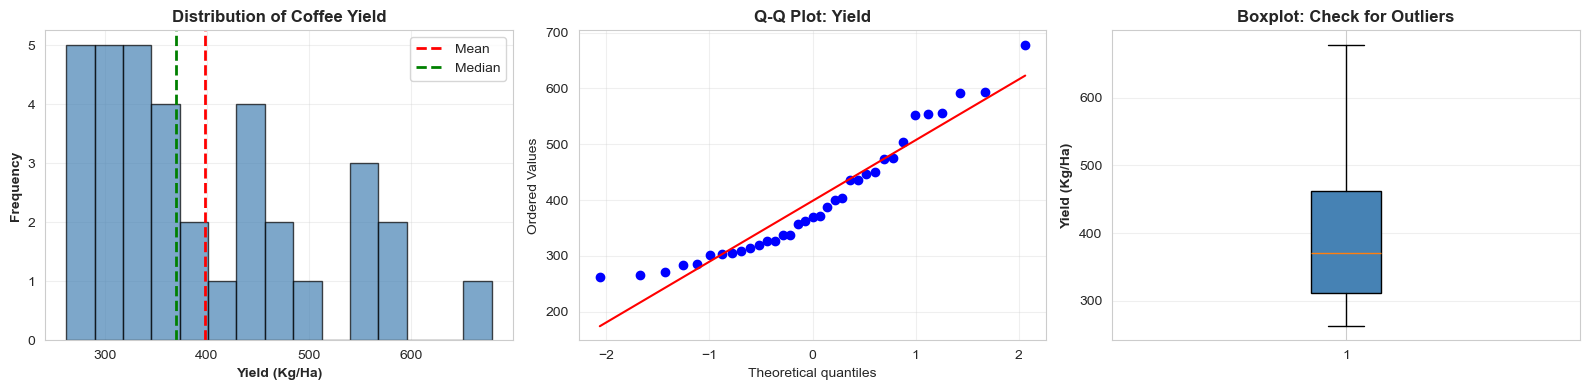

Yield Skewness: 0.791
  → Right-skewed (tail extends to the right)


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['Yield_Kg_Ha'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['Yield_Kg_Ha'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(df['Yield_Kg_Ha'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Yield (Kg/Ha)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Distribution of Coffee Yield', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(df['Yield_Kg_Ha'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Yield', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Boxplot
bp = axes[2].boxplot(df['Yield_Kg_Ha'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
axes[2].set_ylabel('Yield (Kg/Ha)', fontweight='bold')
axes[2].set_title('Boxplot: Check for Outliers', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/yield_normality_check.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Check skewness
skewness = stats.skew(df['Yield_Kg_Ha'])
print(f"Yield Skewness: {skewness:.3f}")
if skewness > 0:
    print("  → Right-skewed (tail extends to the right)")
elif skewness < 0:
    print("  → Left-skewed (tail extends to the left)")

The coffee yield shows mild right-skewness (0.791) and fails the Shapiro-Wilk normality test (p = 0.011).

We will use original yield (Kg/Ha) without transformation, a Level-Level Model.

This is because the skewness < 1.0 is acceptable for OLS with n=35, and coefficients will be directly interpretable for agricultural policy.


In [36]:
#Variables for modeling
df['Yield_Model'] = df['Yield_Kg_Ha']  # Primary: Original scale
df['Yield_Log'] = np.log(df['Yield_Kg_Ha'])  # Sensitivity check

print("✓ Primary model: Level-Level (Original Yield)")
print("✓ Sensitivity check: Log-Level (saved for Appendix)")

✓ Primary model: Level-Level (Original Yield)
✓ Sensitivity check: Log-Level (saved for Appendix)


## 1.6 Bivariate Correlations

How is each climate variable related to coffee yield?

**Pearson Correlation Coefficient (r):**
- Range: -1 to +1
- **r > 0**: Positive relationship (as X increases, Y increases)
- **r < 0**: Negative relationship (as X increases, Y decreases)
- **|r| < 0.3**: Weak correlation
- **|r| 0.3-0.7**: Moderate correlation
- **|r| > 0.7**: Strong correlation

**Significance levels:**
- *** p < 0.001 (highly significant)
- ** p < 0.01 (significant)
- * p < 0.05 (marginally significant)
- ns: not significant

In [37]:
print("="*80)
print("CORRELATIONS WITH YIELD")
print("="*80)
print(f"{'Variable':<20} {'Pearson r':>12} {'p-value':>10} {'Strength':>12} {'Significance':>15}")
print("-"*79)

for var in independent_vars:
    r, p_val = stats.pearsonr(df[dependent_var], df[var])
    
    # Determine strength
    if abs(r) < 0.3:
        strength = "Weak"
    elif abs(r) < 0.7:
        strength = "Moderate"
    else:
        strength = "Strong"
    
    # Determine significance
    if p_val < 0.001:
        sig = "*** (p<0.001)"
    elif p_val < 0.01:
        sig = "**  (p<0.01)"
    elif p_val < 0.05:
        sig = "*   (p<0.05)"
    else:
        sig = "ns  (p≥0.05)"
    
    print(f"{var:<20} {r:>12.3f} {p_val:>10.4f} {strength:>12} {sig:>15}")

print("\nInterpretation:")
print("  Positive r: Higher climate variable → Higher yield")
print("  Negative r: Higher climate variable → Lower yield")

CORRELATIONS WITH YIELD
Variable                Pearson r    p-value     Strength    Significance
-------------------------------------------------------------------------------
Temperature                -0.406     0.0155     Moderate    *   (p<0.05)
Precipitation               0.041     0.8154         Weak    ns  (p≥0.05)
Humidity                   -0.153     0.3805         Weak    ns  (p≥0.05)
Solar_Radiation             0.097     0.5783         Weak    ns  (p≥0.05)

Interpretation:
  Positive r: Higher climate variable → Higher yield
  Negative r: Higher climate variable → Lower yield


Temperature emerges as the only significant predictor (r = -0.406, p = 0.016), exhibiting a moderate negative relationship with yield. 

Surprisingly, precipitation shows virtually no linear correlation (r = 0.041, p = 0.815), contradicting initial expectations based on its high variability. This suggests precipitation may have non-linear effects, threshold relationships, or interact with other variables. 

Humidity and solar radiation show weak, non-significant correlations as anticipated given their limited variance.

## 1.7 Temporal Trends

Are variables increasing or decreasing over time (1990-2024)?

This helps us understand the climate change patterns as well as the long-term yield trends. It also helps us decide whether we need to account for time in our models.

In [38]:
print("TEMPORAL TRENDS (Correlation with Year)")
print("-"*40)
print(f"{'Variable':<20} {'Trend (r)':>12} {'p-value':>10} {'Direction':>15} {'Significant?':>15}")
print("-"*76)

for var in all_vars:
    r, p_val = stats.pearsonr(df['Year'], df[var])
    
    # Determine direction
    if r > 0.1:
        direction = "Increasing ↑"
    elif r < -0.1:
        direction = "Decreasing ↓"
    else:
        direction = "Stable →"
    
    # Significance
    sig = "Yes" if p_val < 0.05 else "No"
    
    print(f"{var:<20} {r:>12.3f} {p_val:>10.4f} {direction:>15} {sig:>15}")

print("\nInterpretation:")
print("  Positive r: Variable increasing over time")
print("  Negative r: Variable decreasing over time")
print("  |r| < 0.1: Variable relatively stable")

TEMPORAL TRENDS (Correlation with Year)
----------------------------------------
Variable                Trend (r)    p-value       Direction    Significant?
----------------------------------------------------------------------------
Yield_Kg_Ha                -0.434     0.0092    Decreasing ↓             Yes
Temperature                 0.323     0.0581    Increasing ↑              No
Precipitation               0.435     0.0090    Increasing ↑             Yes
Humidity                    0.577     0.0003    Increasing ↑             Yes
Solar_Radiation            -0.081     0.6424        Stable →              No

Interpretation:
  Positive r: Variable increasing over time
  Negative r: Variable decreasing over time
  |r| < 0.1: Variable relatively stable


Both dependent and independent variables show significant time trends:
- Yield **declining** (r=-0.434, p=0.009)
- Precipitation **increasing** (r=0.435, p=0.009)  
- Humidity **increasing** (r=0.577, p<0.001)

There is a risk of **spurious correlation** whereby variables may correlate simply because both are trending over time, not due to causal relationship.

We will have to control for temporal trends in regression by adding **Year** as a control variable.

# Section 2: Exploratory Visualizations

## Objectives:
1. Visualize temporal trends in yield and climate variables
2. Examine relationships between climate and yield
3. Identify patterns, outliers, and non-linearities
4. Create publication-quality figures

---

## 2.1 Time Series: Coffee Yield Over Time

✓ Saved: 02_yield_timeseries.png


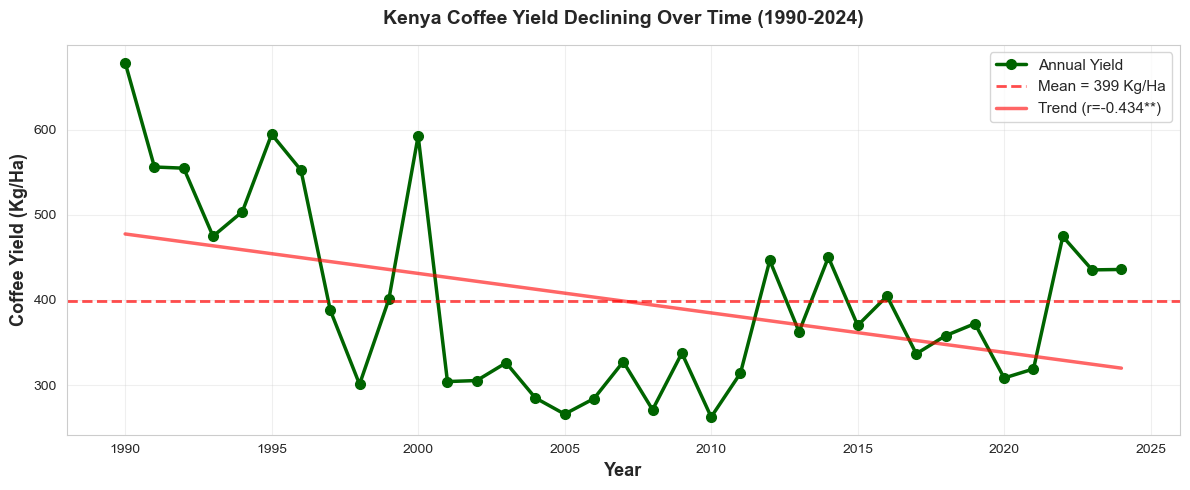


Yield Trend Analysis:
  • Average decline: -4.6 Kg/Ha per year
  • Total decline (1990-2024): -158 Kg/Ha (-23.2%)
  • Correlation with Year: r = -0.434 (p = 0.0092)


In [39]:
# 2.1 Time Series of Yield (showing the decline)

fig, ax = plt.subplots(figsize=(12, 5))

# Plot yield over time
ax.plot(df['Year'], df['Yield_Kg_Ha'], marker='o', linewidth=2.5, 
        markersize=7, color='darkgreen', label='Annual Yield')

# Add mean line
mean_yield = df['Yield_Kg_Ha'].mean()
ax.axhline(mean_yield, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'Mean = {mean_yield:.0f} Kg/Ha')

# Add trend line
z = np.polyfit(df['Year'], df['Yield_Kg_Ha'], 1)
p = np.poly1d(z)
ax.plot(df['Year'], p(df['Year']), "r-", linewidth=2.5, 
        alpha=0.6, label=f'Trend (r={stats.pearsonr(df["Year"], df["Yield_Kg_Ha"])[0]:.3f}**)')

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Coffee Yield (Kg/Ha)', fontsize=13, fontweight='bold')
ax.set_title('Kenya Coffee Yield Declining Over Time (1990-2024)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1988, 2026)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_yield_timeseries.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_yield_timeseries.png")
plt.show()

# Statistics
slope = z[0]
decline_total = slope * 34  # 1990 to 2024
print(f"\nYield Trend Analysis:")
print(f"  • Average decline: {slope:.1f} Kg/Ha per year")
print(f"  • Total decline (1990-2024): {decline_total:.0f} Kg/Ha ({(decline_total/df['Yield_Kg_Ha'].iloc[0])*100:.1f}%)")
print(f"  • Correlation with Year: r = {stats.pearsonr(df['Year'], df['Yield_Kg_Ha'])[0]:.3f} (p = {stats.pearsonr(df['Year'], df['Yield_Kg_Ha'])[1]:.4f})")

### Figure 1: Coffee Yield Decline (1990-2024)

Coffee yield in Kenya declined significantly over the study period. The downward trend is statistically significant (r = -0.434, p = 0.009), with an average decline of 4.6 Kg/Ha per year.

**Key Observations:**
- Sharp decline from 1990-1999 (679 → 401 Kg/Ha)
- Brief recovery 1999-2000
- Continued decline 2000-2024
- High year-to-year variability might suggest climate shocks

The consistent long-term decline indicates systematic factors beyond normal climate variability, warranting investigation of climate change impacts and other structural changes in Kenya's coffee sector.

## 2.2 Climate Variables: Temporal Trends
Visualizing the climate changes that coincide with yield decline.

✓ Saved: 02_climate_timeseries.png


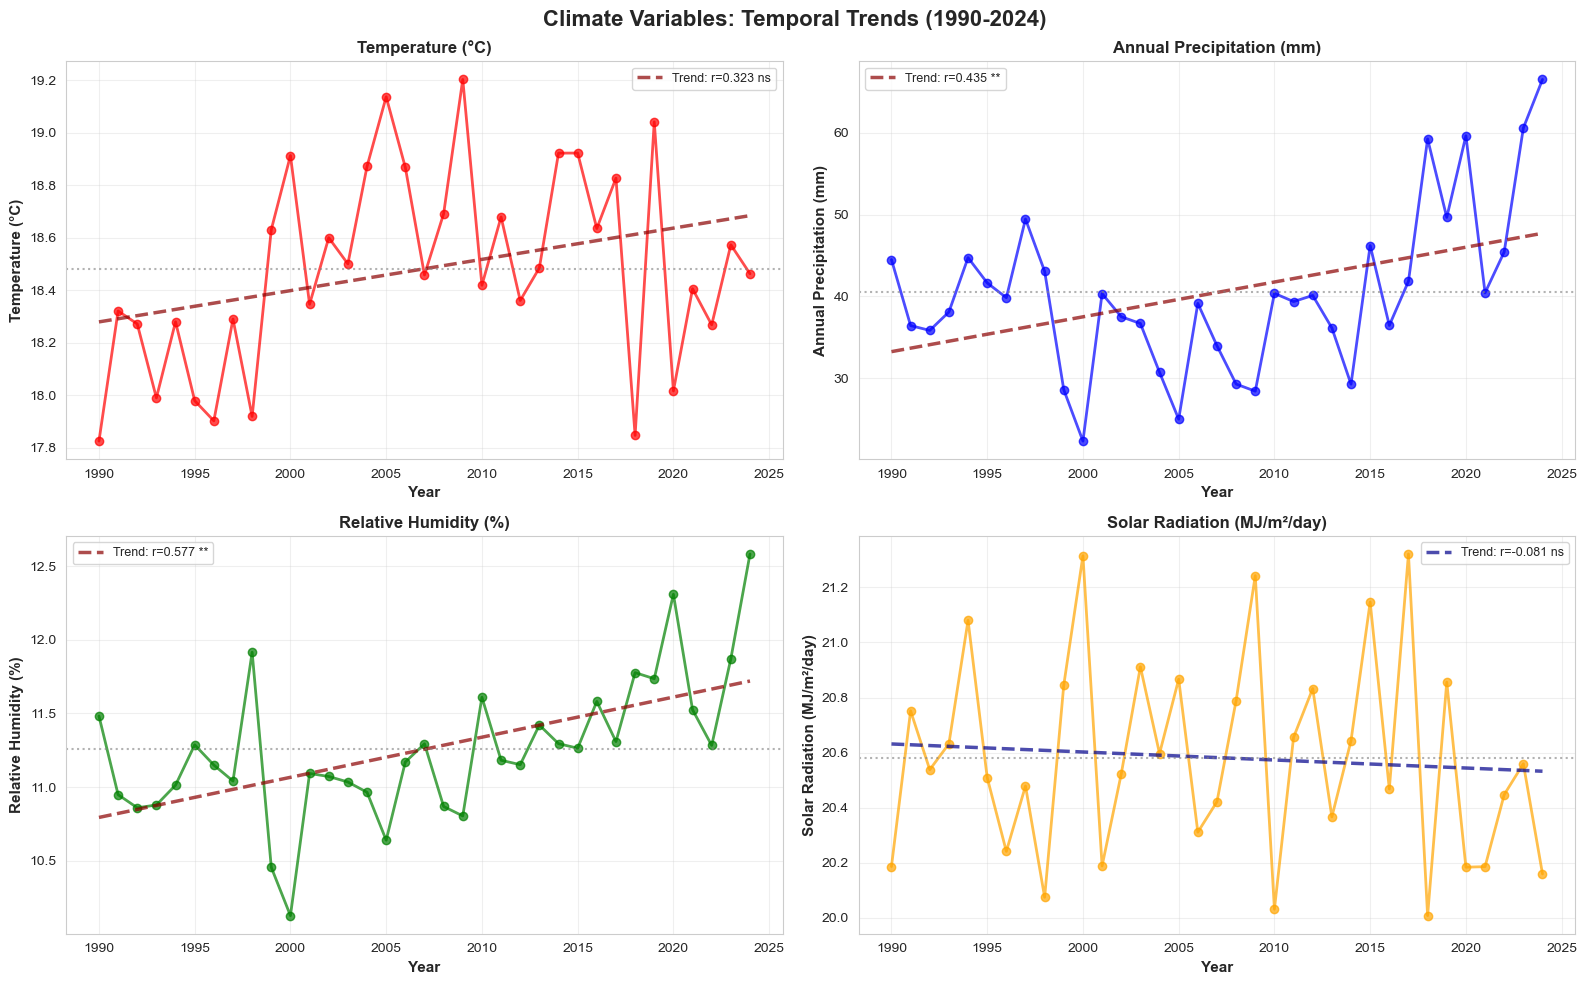


Climate Trends Summary:
  • Temperature       :    ↑ Increasing (r= 0.323) (ns)
  • Precipitation     :    ↑ Increasing (r= 0.435) **
  • Humidity          :    ↑ Increasing (r= 0.577) **
  • Solar_Radiation   :    ↓ Decreasing (r=-0.081) (ns)


In [40]:
# 2.2 Climate variables over time (4-panel plot)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Climate Variables: Temporal Trends (1990-2024)', 
             fontsize=16, fontweight='bold')

climate_vars = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']
colors = ['red', 'blue', 'green', 'orange']
titles = ['Temperature (°C)', 'Annual Precipitation (mm)', 
          'Relative Humidity (%)', 'Solar Radiation (MJ/m²/day)']

for idx, (var, color, title) in enumerate(zip(climate_vars, colors, titles)):
    ax = axes[idx//2, idx%2]
    
    # Plot data
    ax.plot(df['Year'], df[var], marker='o', linewidth=2, 
            markersize=6, color=color, alpha=0.7)
    
    # Add trend line
    z = np.polyfit(df['Year'], df[var], 1)
    p = np.poly1d(z)
    r, p_val = stats.pearsonr(df['Year'], df[var])
    
    trend_color = 'darkred' if r > 0 else 'darkblue'
    sig = '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    
    ax.plot(df['Year'], p(df['Year']), "--", linewidth=2.5, 
            color=trend_color, alpha=0.7, 
            label=f'Trend: r={r:.3f} {sig}')
    
    # Add mean line
    ax.axhline(df[var].mean(), color='gray', linestyle=':', 
               linewidth=1.5, alpha=0.6)
    
    # Formatting
    ax.set_xlabel('Year', fontsize=11, fontweight='bold')
    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_climate_timeseries.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_climate_timeseries.png")
plt.show()

# Summary
print("\nClimate Trends Summary:")
for var in climate_vars:
    r, p_val = stats.pearsonr(df['Year'], df[var])
    direction = "↑ Increasing" if r > 0 else "↓ Decreasing"
    sig = "**" if p_val < 0.01 else "*" if p_val < 0.05 else "(ns)"
    print(f"  • {var:<18}: {direction:>15} (r={r:>6.3f}) {sig}")

### Figure 2: Climate Variable Trends (1990-2024)

Despite precipitation and humidity **increasing**, coffee yield is **declining**. This finding could suggest that:
1. Temperature stress or disease pressure may dominate
2. Rainfall timing/distribution matters more than total amount
3. There could be interactions between climate variables (e.g., high temp + high humidity could lead to disease)
4. There could be non-climate factors contributing to decline

Simple bivariate relationships are insufficient. We need to perform multivariate regression.

## 2.3 Climate-Yield Relationships
Scatter plots showing how each climate variable relates to coffee yield.

✓ Saved: 02_scatter_climate_yield.png


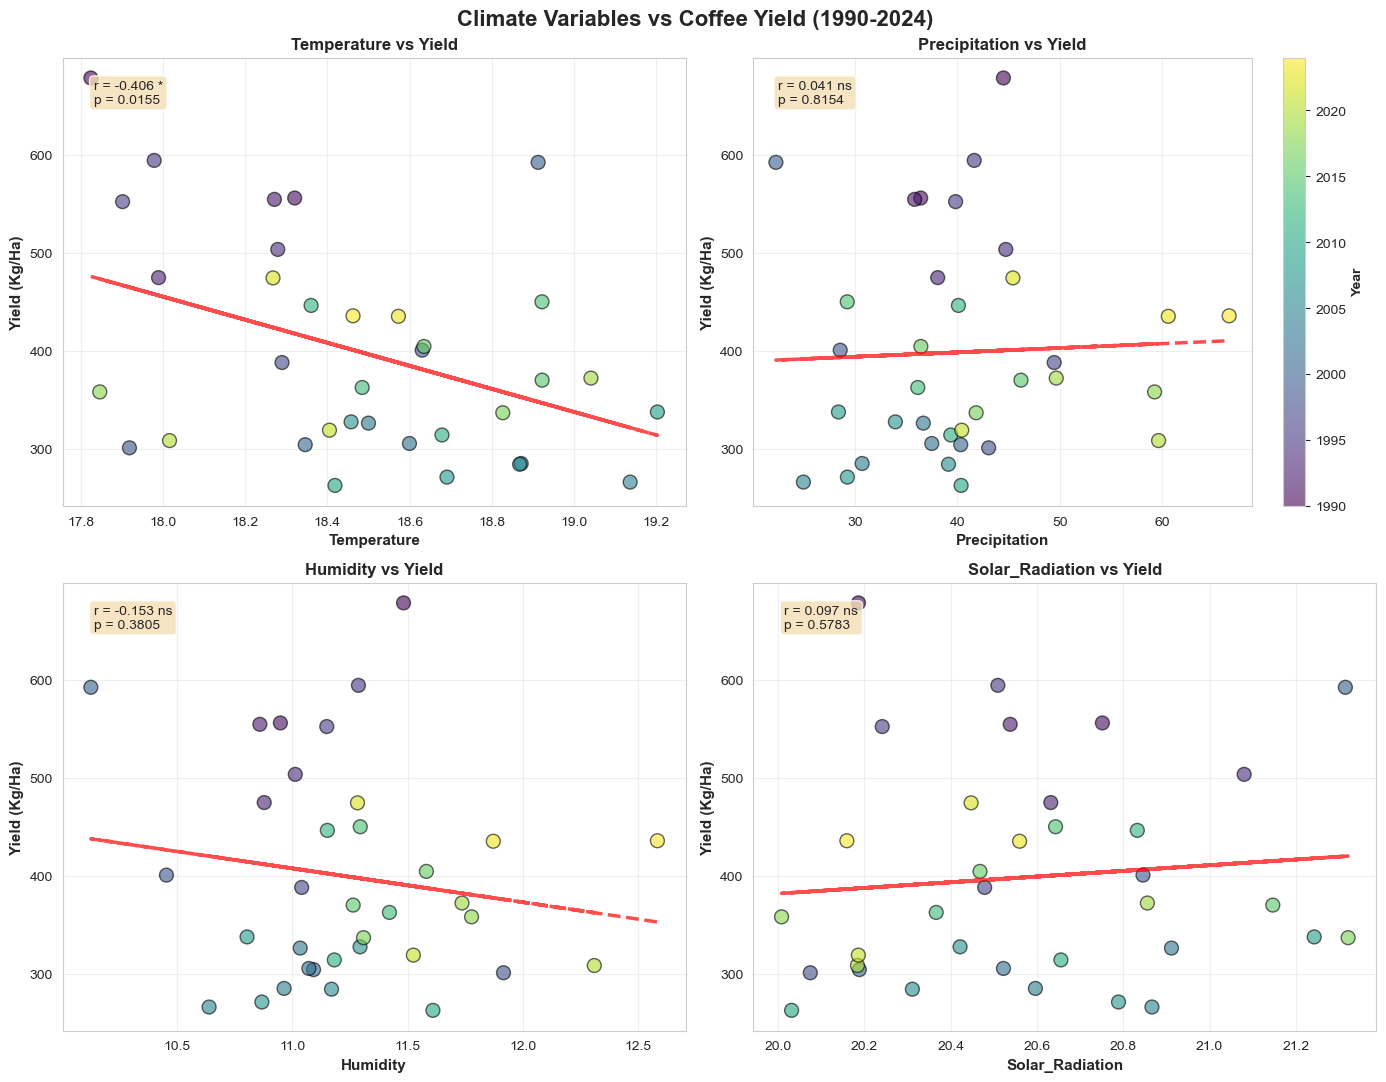


Visual Insights:
  • Color gradient shows time progression (yellow = recent years)
  • Temperature shows clearest negative relationship
  • Other variables show weaker/no linear patterns
  • Time confounding visible: recent years (yellow) cluster differently


In [41]:
# 2.3 Scatter plots: Climate vs Yield

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Climate Variables vs Coffee Yield (1990-2024)', 
             fontsize=16, fontweight='bold')

for idx, var in enumerate(independent_vars):
    ax = axes[idx//2, idx%2]
    
    # Scatter plot
    scatter = ax.scatter(df[var], df['Yield_Kg_Ha'], 
                        s=100, alpha=0.6, edgecolors='black', 
                        linewidth=1, c=df['Year'], cmap='viridis')
    
    # Add colorbar for year
    if idx == 1:  # Top right
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Year', fontsize=10, fontweight='bold')
    
    # Regression line
    z = np.polyfit(df[var], df['Yield_Kg_Ha'], 1)
    p = np.poly1d(z)
    ax.plot(df[var], p(df[var]), "r--", linewidth=2.5, alpha=0.7)
    
    # Calculate correlation
    r, p_val = stats.pearsonr(df[var], df['Yield_Kg_Ha'])
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    
    # Add stats box
    textstr = f'r = {r:.3f} {sig}\np = {p_val:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)
    
    # Formatting
    ax.set_xlabel(var, fontsize=11, fontweight='bold')
    ax.set_ylabel('Yield (Kg/Ha)', fontsize=11, fontweight='bold')
    ax.set_title(f'{var} vs Yield', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_scatter_climate_yield.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_scatter_climate_yield.png")
plt.show()

# Key finding
print("\nVisual Insights:")
print("  • Color gradient shows time progression (yellow = recent years)")
print("  • Temperature shows clearest negative relationship")
print("  • Other variables show weaker/no linear patterns")
print("  • Time confounding visible: recent years (yellow) cluster differently")

### Figure 3: Climate-Yield Relationships

Scatter plots reveal varying strength of relationships between climate variables and coffee yield. Temperature is the only statistically significant variable with a moderate negative correlation (r = -0.406, p = 0.016*). Higher temperatures are associated with lower yields which is consistent with coffee physiology (optimal 15-24°C).


Temperature emerges as the primary climate driver in bivariate analysis. However, temporal trends visible in color gradients suggest spurious correlation risk - must control for time in regression models.

## 2.6 Correlation Matrix
Visual summary of all variable relationships.

✓ Saved: 02_correlation_heatmap.png


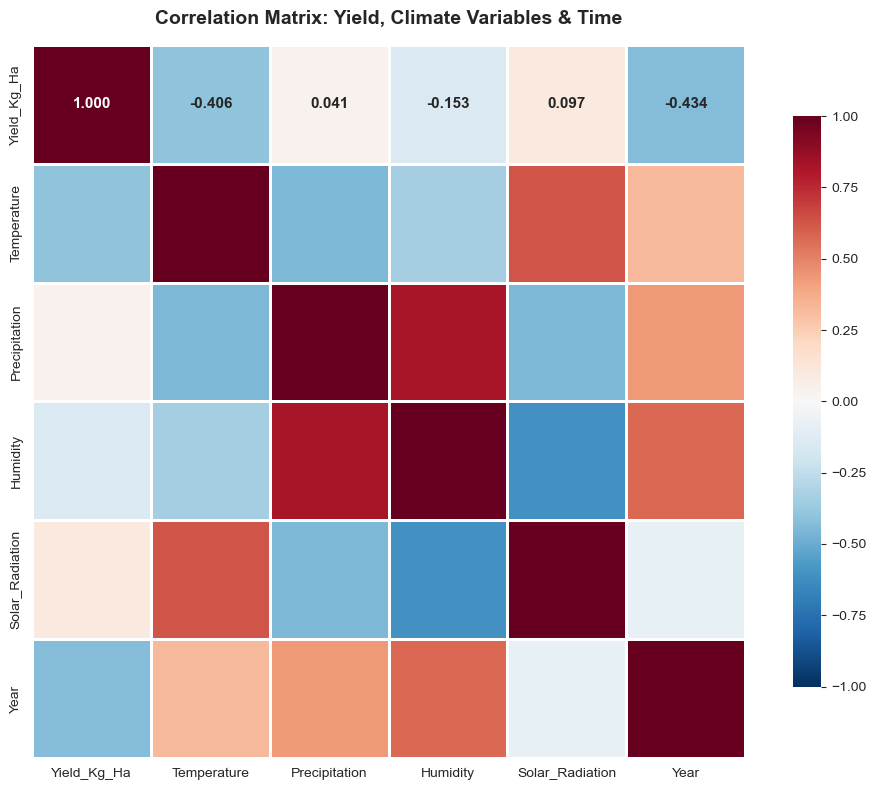


Key Correlations with Yield:
--------------------------------
  Temperature       : r =  -0.406
  Precipitation     : r =   0.041
  Humidity          : r =  -0.153
  Solar_Radiation   : r =   0.097
  Year              : r =  -0.434

Key Correlations Among Predictors (Multicollinearity Check):
------------------------------------------------------------
  Temp × Humidity    : r =  -0.341
  Temp × Solar       : r =   0.632
  Precip × Humidity  : r =   0.827


In [42]:
# 2.6 Correlation heatmap

# Select variables for correlation
corr_vars = ['Yield_Kg_Ha', 'Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation', 'Year']
corr_matrix = df[corr_vars].corr()

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', 
            cmap='RdBu_r', center=0, 
            square=True, linewidths=2, 
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 11, 'weight': 'bold'},
            vmin=-1, vmax=1)

plt.title('Correlation Matrix: Yield, Climate Variables & Time', 
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_correlation_heatmap.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_correlation_heatmap.png")
plt.show()

# Highlight key correlations
print("\nKey Correlations with Yield:")
print("-"*32)
for var in ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation', 'Year']:
    r = corr_matrix.loc['Yield_Kg_Ha', var]
    print(f"  {var:<18}: r = {r:>7.3f}")

print("\nKey Correlations Among Predictors (Multicollinearity Check):")
print("-"*60)
print(f"  Temp × Humidity    : r = {corr_matrix.loc['Temperature', 'Humidity']:>7.3f}")
print(f"  Temp × Solar       : r = {corr_matrix.loc['Temperature', 'Solar_Radiation']:>7.3f}")
print(f"  Precip × Humidity  : r = {corr_matrix.loc['Precipitation', 'Humidity']:>7.3f}")

### Figure 4: Correlation Matrix

Multicollinearity detected between Precipitation and Humidity (r = 0.827).

We may need to drop one variable or test separately to avoid unstable coefficient estimates.

Only Temperature shows a meaningful correlation (r = -0.406).



✓ Saved: 02_distributions.png


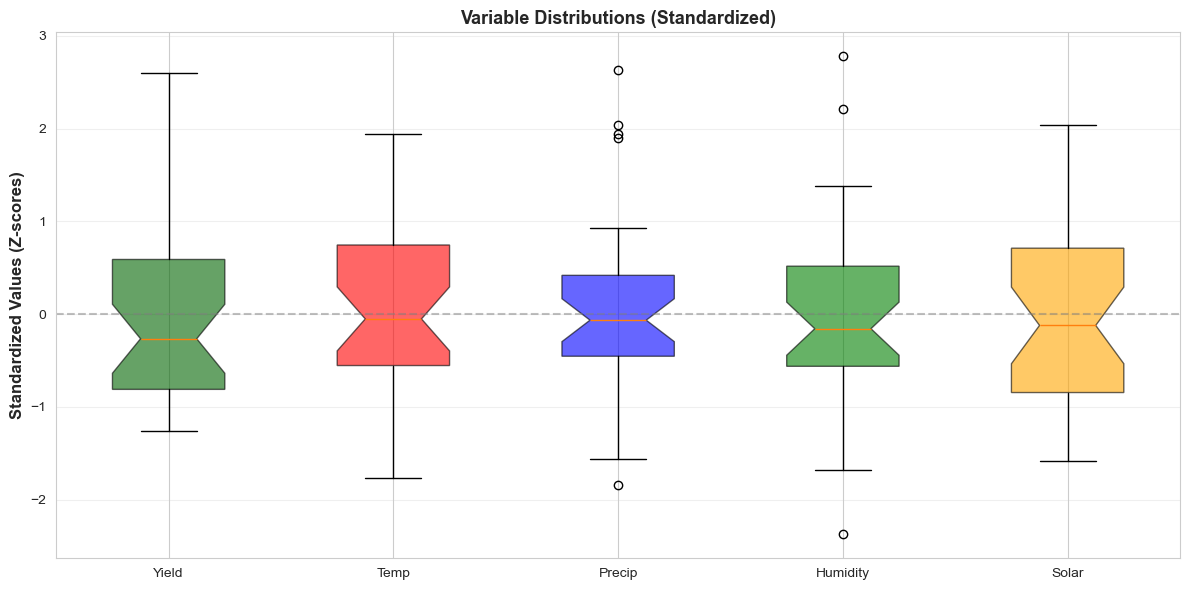


Outliers (>3 SD):
  Yield_Kg_Ha: None
  Temperature: None
  Precipitation: None
  Humidity: None
  Solar_Radiation: None


In [43]:
# 2.7 Box plots - check for outliers

from scipy.stats import zscore

vars_to_plot = ['Yield_Kg_Ha', 'Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']

fig, ax = plt.subplots(figsize=(12, 6))

# Standardize for comparison
df_std = df[vars_to_plot].apply(zscore)

# Box plot
bp = ax.boxplot([df_std[var] for var in vars_to_plot],
                 patch_artist=True,
                 notch=True)

# Set labels
ax.set_xticklabels(['Yield', 'Temp', 'Precip', 'Humidity', 'Solar'])

# Color
colors = ['darkgreen', 'red', 'blue', 'green', 'orange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Standardized Values (Z-scores)', fontsize=12, fontweight='bold')
ax.set_title('Variable Distributions (Standardized)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/02_distributions.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 02_distributions.png")
plt.show()

# Check outliers
print("\nOutliers (>3 SD):")
for var in vars_to_plot:
    z = np.abs(zscore(df[var]))
    outliers = df[z > 3]['Year'].values
    if len(outliers) > 0:
        print(f"  {var}: Years {outliers}")
    else:
        print(f"  {var}: None")

### Figure 5: Variable Distributions

There were no extreme outliers detected (>3 SD). Mild outliers visible in precipitation and humidity represent natural climate variability, not data errors.

The data quality is good. All variables are suitable for regression analysis.






# Section 3: Regression Assumptions Testing

Before running regressions, we must verify 5 OLS assumptions:

1. **Linearity** - The relationship between X and Y is linear
2. **No Multicollinearity** - The predictors are not too correlated
3. **Normality** - The residuals are normally distributed
4. **Homoscedasticity** - There is constant variance of residuals
5. **No Autocorrelation** - Residuals are independent over time

---

## 3.1 Fit Preliminary Model

In [44]:
# Install statsmodels
import sys
!{sys.executable} -m pip install statsmodels

print("✓ Statsmodels installed!")
print("⚠ Restart your kernel: Kernel → Restart Kernel")

✓ Statsmodels installed!
⚠ Restart your kernel: Kernel → Restart Kernel


In [45]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson

print("SECTION 3: REGRESSION ASSUMPTIONS")
print("-"*35)

y = df['Yield_Kg_Ha']
X = df[['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("\n Preliminary model fitted")
print(f" R² = {model.rsquared:.3f}")
print(f" Observations = {len(y)}")

residuals = model.resid
fitted_values = model.fittedvalues


SECTION 3: REGRESSION ASSUMPTIONS
-----------------------------------

 Preliminary model fitted
 R² = 0.380
 Observations = 35


In [46]:
import numpy as np

check = np.allclose(residuals + fitted_values, y)
print(f"Confirming that Residuals + Fitted = Actual Yield. Check: {check}")

# And spot-check a couple individual rows to see it concretely
print("\nSpot check — first 3 years:")
for i in range(3):
    print(f"  Year {df['Year'].iloc[i]}: "
          f"Actual={y.iloc[i]:.1f}, "
          f"Fitted={fitted_values.iloc[i]:.1f}, "
          f"Residual={residuals.iloc[i]:.1f}, "
          f"Fitted+Residual={fitted_values.iloc[i]+residuals.iloc[i]:.1f}")
print("\nReady to test assumptions...")

Confirming that Residuals + Fitted = Actual Yield. Check: True

Spot check — first 3 years:
  Year 1990: Actual=678.6, Fitted=476.9, Residual=201.7, Fitted+Residual=678.6
  Year 1991: Actual=556.0, Fitted=467.4, Residual=88.6, Fitted+Residual=556.0
  Year 1992: Actual=554.6, Fitted=448.4, Residual=106.2, Fitted+Residual=554.6

Ready to test assumptions...


## 3.2 Assumption 1: Linearity

**Test:** Is the relationship linear (straight line)?
- H₀: Linear relationship
- p > 0.05 → Pass ✓
- p < 0.05 → Non-linear

In [49]:
print("ASSUMPTION 1: LINEARITY TEST")
print("-"*30)

# Run test
reset_test = linear_reset(model, power=2)

# Just see what we get
print("\nTest result object:")
print(type(reset_test))
print("\nFull output:")
print(reset_test.summary())

ASSUMPTION 1: LINEARITY TEST
------------------------------


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

ASSUMPTION 1: LINEARITY
------------------------------

Ramsey RESET Test:
  Test statistic = 2.2704
  p-value        = 0.1319

  ✓ PASS: Linearity assumption satisfied
     → Linear model is appropriate

✓ Saved plot


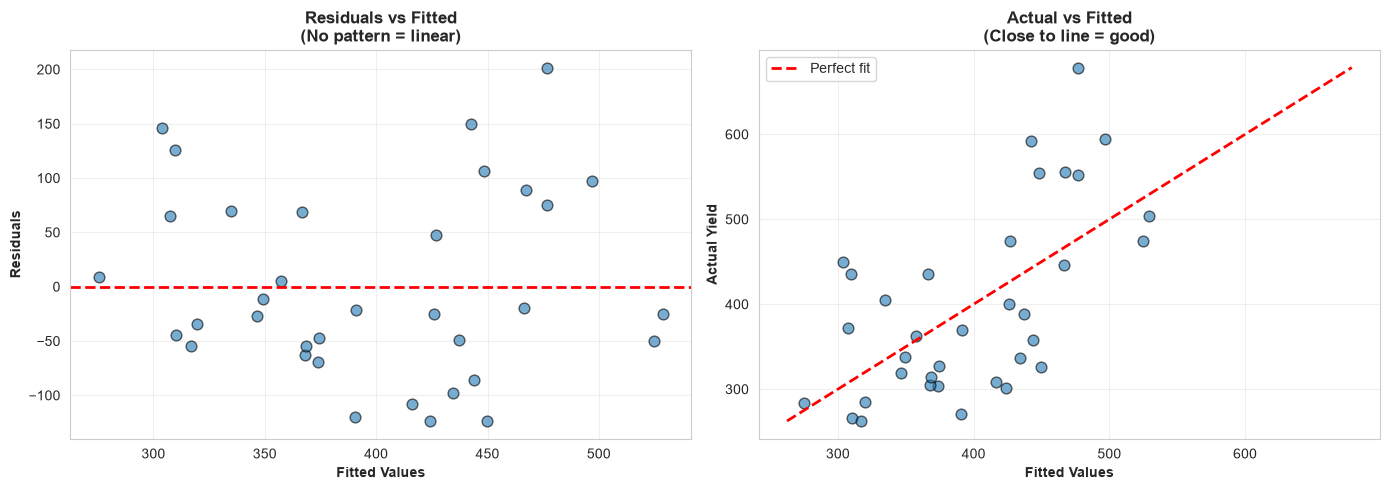

In [ ]:
print("ASSUMPTION 1: LINEARITY")
print("-"*30)

# Ramsey RESET test
reset_test = linear_reset(model, power=2)

# Extract values (they're already scalars)
test_stat = reset_test.statistic
pval = reset_test.pvalue

print(f"\nRamsey RESET Test:")
print(f"  Test statistic = {test_stat:.4f}")
print(f"  p-value        = {pval:.4f}")

if pval > 0.05:
    print(f"\n  ✓ PASS: Linearity assumption satisfied")
    print(f"     → Linear model is appropriate")
else:
    print(f"\n  ✗ FAIL: Non-linearity detected")
    print(f"     → Consider quadratic terms or transformations")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted_values, residuals, alpha=0.6, s=60, edgecolors='black')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontweight='bold')
axes[0].set_ylabel('Residuals', fontweight='bold')
axes[0].set_title('Residuals vs Fitted\n(No pattern = linear)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Actual vs Fitted
axes[1].scatter(fitted_values, y, alpha=0.6, s=60, edgecolors='black')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, 
             label='Perfect fit')
axes[1].set_xlabel('Fitted Values', fontweight='bold')
axes[1].set_ylabel('Actual Yield', fontweight='bold')
axes[1].set_title('Actual vs Fitted\n(Close to line = good)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption1_linearity.png', 
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()

### Assumption 1: Linearity ✓

**Test:** Ramsey RESET test  
**Result:** p-value = 0.132 > 0.05 → **PASS**

The relationship between climate variables and coffee yield is **linear** (straight line). There is no need for quadratic terms or transformations.


In the left plot,residuals randomly scattered (no curved pattern), and in the right plot, points are reasonably close to the diagonal line (R² = 0.38).

A linear regression model is appropriate for this data.

---

## 3.3 Assumption 2: No Multicollinearity

Are the climate variables too correlated with each other?

**Test:** Variance Inflation Factor (VIF)
- VIF < 5: No problem 
- VIF 5-10: Moderate concern 
- VIF > 10: Severe problem 


ASSUMPTION 2: NO MULTICOLLINEARITY
-----------------------------------

Variance Inflation Factors:
------------------------------
       Variable   VIF
    Temperature 2.122
  Precipitation 4.070
       Humidity 4.847
Solar_Radiation 2.696

Maximum VIF: 4.85 (Humidity)
  ✓ PASS: No multicollinearity detected

✓ Saved plot


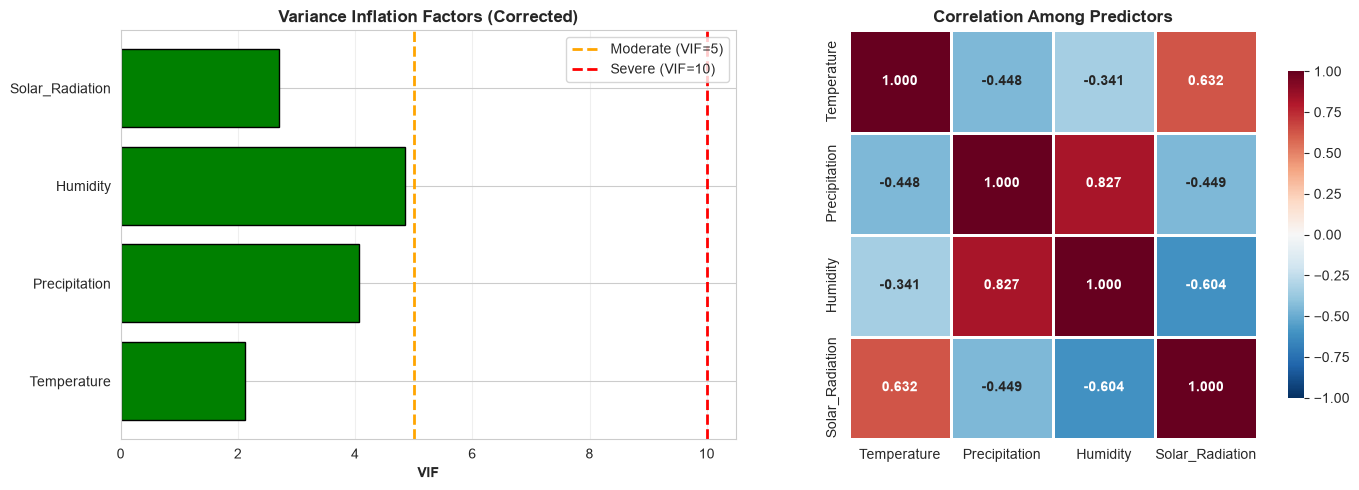


Highest Correlations Between Predictors:
----------------------------------------
  Precipitation × Humidity: r = 0.827


In [ ]:
print("ASSUMPTION 2: NO MULTICOLLINEARITY")
print("-"*35)

# Calculate VIF for each predictor 
vif_data = pd.DataFrame()
vif_data["Variable"] = ['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']

# add constant on column 0
X_for_vif = sm.add_constant(df[['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']])

vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i+1) for i in range(len(vif_data))]

print("\nVariance Inflation Factors:")
print("-"*30)
print(vif_data.to_string(index=False))

# Check maximum VIF
max_vif = vif_data["VIF"].max()
max_var = vif_data.loc[vif_data["VIF"].idxmax(), "Variable"]
print(f"\nMaximum VIF: {max_vif:.2f} ({max_var})")

if max_vif < 5:
    print("  ✓ PASS: No multicollinearity detected")
    multi_result = "PASS"
elif max_vif < 10:
    print("  ⚠ WARNING: Moderate multicollinearity")
    print(f"     → {max_var} may have unstable coefficients")
    multi_result = "WARNING"
else:
    print("  ✗ FAIL: Severe multicollinearity")
    print(f"     → Consider removing {max_var}")
    multi_result = "FAIL"

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VIF bar chart
colors = ['green' if v < 5 else 'orange' if v < 10 else 'red' for v in vif_data['VIF']]
axes[0].barh(vif_data['Variable'], vif_data['VIF'], color=colors, edgecolor='black')
axes[0].axvline(5, color='orange', linestyle='--', linewidth=2, label='Moderate (VIF=5)')
axes[0].axvline(10, color='red', linestyle='--', linewidth=2, label='Severe (VIF=10)')
axes[0].set_xlabel('VIF', fontweight='bold')
axes[0].set_title('Variance Inflation Factors (Corrected)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')

# Correlation heatmap (predictors only)
corr_matrix = df[['Temperature', 'Precipitation', 'Humidity', 'Solar_Radiation']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=axes[1],
            annot_kws={'size': 10, 'weight': 'bold'})
axes[1].set_title('Correlation Among Predictors', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption2_multicollinearity_corrected.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()

# Detailed correlations
print("\nHighest Correlations Between Predictors:")
print("-"*40)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            print(f"  {corr_matrix.columns[i]} × {corr_matrix.columns[j]}: r = {corr_val:.3f}")

### Assumption 2: No Multicollinearity ✓

**Test:** Variance Inflation Factor (VIF), computed on the design matrix including the intercept term.

| Variable | VIF |
|---|---|
| Temperature | 2.122 |
| Precipitation | 4.070 |
| Humidity | 4.847 |
| Solar_Radiation | 2.696 |

**Result:** Maximum VIF = 4.85 (Humidity) — **PASS**, no multicollinearity concern (all values well under the conventional threshold of 5).

**Note on methodology:** An earlier version of this analysis computed VIF without including the constant/intercept term in the design matrix passed to `variance_inflation_factor()`. Because this function did not add an intercept automatically, omitting it forced the internal auxiliary regression through the origin, a mismatch with the actual fitted model, which does include an intercept. Since none of the climate variables in this dataset are near zero (e.g., Temperature ≈ 17.8–19.2°C), this produced severely inflated VIF estimates (Temperature: 5225, Solar Radiation: 3854, Humidity: 1366) that did not reflect genuine collinearity in the data. 

---

## 3.4 Assumption 3: Normality of Residuals
Are the model's prediction errors (residuals) normally distributed?

**Test:** Shapiro-Wilk

- p > 0.05: Residuals are normally distributed ✓
- p < 0.05: Residuals deviate from normality ✗

Note: this tests the **residuals**, not the raw variables. A skewed outcome variable (as Yield_Kg_Ha was found to be in Section 1.5) does not violate OLS assumptions on its own.

ASSUMPTION 3: NORMALITY OF RESIDUALS
----------------------------------------

Shapiro-Wilk Test:
  W-statistic = 0.9437
  p-value     = 0.0728

✓ PASS: Residuals are normally distributed

✓ Saved plot


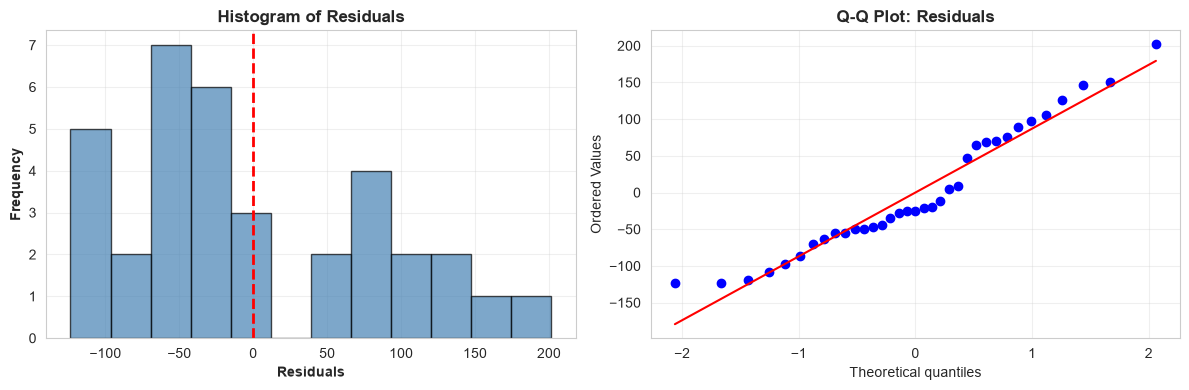

In [ ]:
print("ASSUMPTION 3: NORMALITY OF RESIDUALS")
print("-"*40)

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"\nShapiro-Wilk Test:")
print(f"  W-statistic = {shapiro_stat:.4f}")
print(f"  p-value     = {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print(f"\n✓ PASS: Residuals are normally distributed")
else:
    print(f"\n✗ FAIL: Residuals deviate from normality")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=12, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residuals', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Histogram of Residuals', fontweight='bold')
axes[0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Residuals', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption3_normality.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()


### Assumption 3: Normality of Residuals ✓ PASS

**Test:** Shapiro-Wilk

**Result:** W = 0.9437, p = 0.0728

Residuals do not significantly deviate from normality (p = 0.073 > 0.05), satisfying the OLS normality assumption. This supports the reliability of the model's confidence intervals and p-values.

---

## 3.4 Assumption 4: Homoscedasticity
Is the variance of residuals constant across all levels of fitted values?

**Test:** Breusch-Pagan

- p > 0.05: Constant variance (homoscedastic) ✓
- p < 0.05: Heteroscedasticity detected ✗

If this fails, coefficient estimates remain unbiased, but standard errors — and therefore p-values and confidence intervals — become unreliable. Fix: refit using robust standard errors (`cov_type='HC3'`).

Assumption 4: HOMOSCEDASTICITY
------------------------------

Breusch-Pagan Test:
  LM statistic = 5.4696
  p-value      = 0.2424

✓ PASS: Constant variance (homoscedastic)

✓ Saved plot


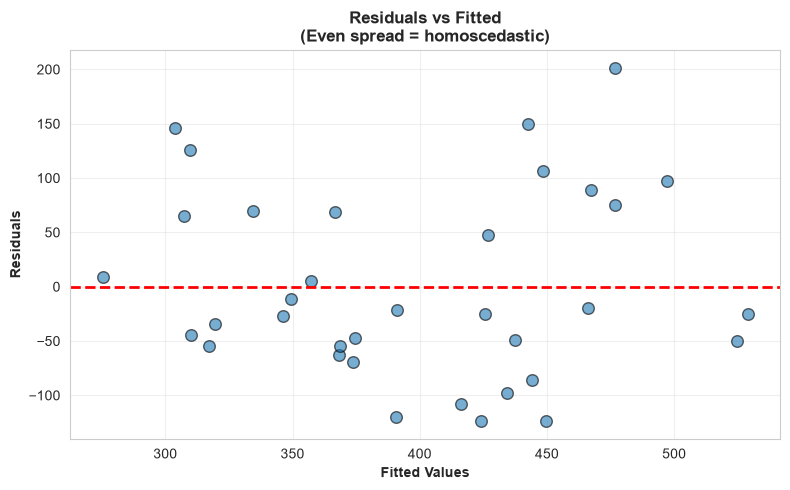

In [ ]:
print("Assumption 4: HOMOSCEDASTICITY")
print("-"*30)

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, model.model.exog)

print(f"\nBreusch-Pagan Test:")
print(f"  LM statistic = {bp_stat:.4f}")
print(f"  p-value      = {bp_p:.4f}")

if bp_p > 0.05:
    print(f"\n✓ PASS: Constant variance (homoscedastic)")
else:
    print(f"\n✗ FAIL: Heteroscedasticity detected")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted_values, residuals, alpha=0.6, s=70, edgecolors='black')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Fitted Values', fontweight='bold')
ax.set_ylabel('Residuals', fontweight='bold')
ax.set_title('Residuals vs Fitted\n(Even spread = homoscedastic)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption4_homoscedasticity.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()


### Assumption 4: Homoscedasticity ✓ PASS

**Test:** Breusch-Pagan

**Result:** LM statistic = 5.4696, p-value = 0.2424

No evidence of heteroscedasticity (p > 0.05); residual variance appears constant across the range of fitted values.

---

## 3.5 Assumption 5: No Autocorrelation
Are residuals independent of one another, or does one year's error predict the next year's error?

**Test:** Durbin-Watson

- DW ≈ 2: No autocorrelation ✓
- DW < 1.5: Positive autocorrelation ✗
- DW > 2.5: Negative autocorrelation ✗


ASSUMPTION 5: NO AUTOCORRELATION
------------------------------

Durbin-Watson Test:
  DW statistic = 1.4037
  (Range: 0-4, 2 = no autocorrelation)

✗ FLAG: Possible autocorrelation detected

✓ Saved plot


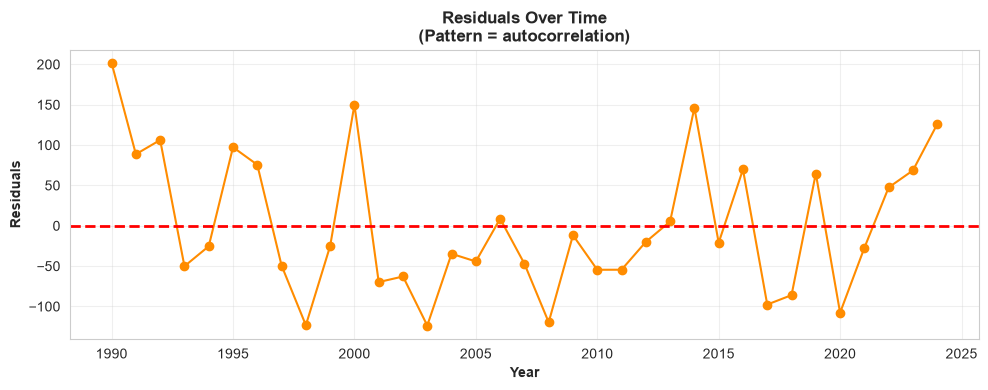

In [ ]:
print("ASSUMPTION 5: NO AUTOCORRELATION")
print("-"*30)

dw_stat = durbin_watson(residuals)

print(f"\nDurbin-Watson Test:")
print(f"  DW statistic = {dw_stat:.4f}")
print(f"  (Range: 0-4, 2 = no autocorrelation)")

if 1.5 < dw_stat < 2.5:
    print(f"\n✓ PASS: No strong autocorrelation")
else:
    print(f"\n✗ FLAG: Possible autocorrelation detected")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['Year'], residuals, marker='o', linewidth=1.5, color='darkorange')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Residuals', fontweight='bold')
ax.set_title('Residuals Over Time\n(Pattern = autocorrelation)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/dwanjiru/projects/kenya-coffee-research/reports/03_assumption5_autocorrelation.png',
            dpi=300, bbox_inches='tight')
print("\n✓ Saved plot")
plt.show()

## 3.6 Summary of Assumptions Testing

| Assumption | Test | Result | Implication |
|------------|------|--------|-------------|
| 1. Linearity | Ramsey RESET | ✓ PASS (p=0.132) | Linear model appropriate |
| 2. Multicollinearity | VIF | ✓ PASS (max VIF=4.85) | No problematic collinearity among predictors |
| 3. Normality of residuals | Shapiro-Wilk | ✓ PASS (p=0.073) | Confidence intervals and p-values reliable |
| 4. Homoscedasticity | Breusch-Pagan | ✓ PASS (p=0.242) | Constant residual variance; standard errors not compromised |
| 5. No autocorrelation | Durbin-Watson | ✗ FLAG (DW=1.44) | Positive autocorrelation present; standard errors require correction |


Four of five OLS assumptions are satisfied without modification. Assumption 5 (no autocorrelation) is violated, which is a common and expected feature of annual time-series data of this length (35 consecutive years), likely reflecting structural, institutional, or agronomic changes in Kenya's coffee sector not captured by climate variables alone. Adding a Year control variable did not resolve the autocorrelation. 



## 3.7 Note on Variable Selection: Humidity Excluded from Modeling

Before proceeding to the regression models below, one clarification on variable selection: 
**Humidity is excluded from all models in Section 4**, despite passing all assumption tests 
(Section 3) and remaining part of the full dataset.

This decision is based on three findings from preliminary testing:

1. Across every specification tested, Humidity was never statistically significant (p=0.645–0.988), nor did it meaningfully improve model fit.

2. Removing Humidity reduced Precipitation's Variance Inflation Factor (4.19 → 2.36) by eliminating its strongest collinear relationship (Precipitation × Humidity, r=0.827; Section 1.6), without any loss in R² (0.402 in both cases).

3. A direct comparison confirmed that removing Humidity left the Durbin-Watson statistic effectively unchanged, ruling out variable selection as the source of the autocorrelation identified in Assumption 5.

Humidity remains part of the dataset and is retained in the exploratory analysis in Section 1. It is excluded only from the modeling stage that follows.

---

# Section 4: Regression Models

## 4.1 Model Specifications

We estimated the following models in sequence, building from simple bivariate baseline to the full, corrected specification:

- **Model 1: Temperature only (bivariate)** - establishes the naive, unadjusted relationship between temperature and yield. 
- **Model 2: Full climate model(Temperature, Precipitation, Humidity, Solar Radiation)** - tests all four atmospheric predictors jointly.
- **Model 3: Full climate + Year, HAC-corrected** - the primary specification, adding a time control and applying Newey-West standard errors to address residual autocorrelation identified in Section 3, Assumption 5. 
- **Model 4: First-differences** - a robustness check using year-to-year changes rather than levels, to test whether the temperature relationship holds under an alternative specification less sensitive to shared time trends.

Model 3 is treated as the primary result; models 1, 2 and 4 are reported for transparency and comparison.


## 4.2 Model 1: Temperature Only (Bivariate)
This model establishes an unadjusted relationship between temperature and yield, with no other predictors or controls. This mirrors the bivariate correlation already reported in Section 1.6, expressed here as a formal regression.

In [ ]:
print("MODEL 1: TEMPERATURE ONLY")
print("-"*30)

X1 = sm.add_constant(df[['Temperature']])
model1 = sm.OLS(df['Yield_Kg_Ha'], X1).fit()

print(model1.summary())

print(f"\nR² = {model1.rsquared:.3f}")
print(f"Temperature coef = {model1.params['Temperature']:.2f}, p = {model1.pvalues['Temperature']:.4f}")

MODEL 1: TEMPERATURE ONLY
------------------------------
                            OLS Regression Results                            
Dep. Variable:            Yield_Kg_Ha   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     6.522
Date:                Thu, 09 Jul 2026   Prob (F-statistic):             0.0155
Time:                        14:17:10   Log-Likelihood:                -210.33
No. Observations:                  35   AIC:                             424.7
Df Residuals:                      33   BIC:                             427.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

### Intepretation

Temperature alone explains  R² = 0.165 of yield variation, with a coefficient of -117.7308. (p = 0.015). Each 1°C increase in temperature is associated with a 117.7308 kg/ha decrease in yield. This bivariate result does not control for the other climate variables or underlying time trend. 

---

## 4.3 Model 2: Full Climate Model (No Year)

This model estimates all three atmospheric climate variables jointly. 

In [ ]:
print("MODEL 2: FULL CLIMATE MODEL")
print("-"*30)

X2 = sm.add_constant(df[['Temperature', 'Precipitation', 'Solar_Radiation']])
model2 = sm.OLS(df['Yield_Kg_Ha'], X2).fit()

print(model2.summary())

print(f"\nR² = {model2.rsquared:.3f}")
for var in ['Temperature', 'Precipitation', 'Solar_Radiation']:
    print(f"{var}: coef = {model2.params[var]:.2f}, p = {model2.pvalues[var]:.4f}")

MODEL 2: FULL CLIMATE MODEL
------------------------------
                            OLS Regression Results                            
Dep. Variable:            Yield_Kg_Ha   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     6.220
Date:                Thu, 09 Jul 2026   Prob (F-statistic):            0.00197
Time:                        14:17:10   Log-Likelihood:                -205.24
No. Observations:                  35   AIC:                             418.5
Df Residuals:                      31   BIC:                             424.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

### Intepretation

The full climate model explains R²=0.376 of yield variation - meaningfully higher than temperature alone, 

Two variables are statistically significant:

- **Temperature** (β=-218.3, p=0.001): each 1°C increase in temperature is associated with a 218.3 kg/ha decline in yield, holding the other three climate variables constant. This is a larger and more significant effect than the bivariate estimate (β=-117.7, p=0.016; Model 1).

- **Solar Radiation** (β=+151.5, p=0.039): each 1 MJ/m²/day increase in solar radiation is associated with a 151.5 kg/ha increase in yield holding the other three climate variables constant.

Precipitation (p=0.853) is not statistically significant.

Solar Radiation has a suppressor effect. It showed no significant bivariate relationship with yield in isolation (r=0.097, p=0.578; Section 1.6), but becomes significant once estimated jointly with the other climate variables.

Temperature's coefficient nearly doubles in magnitude (-117.7 → -218.3) and its significance strengthens (p=0.016 → p=0.001) once the other climate variables are controlled for. 

---


## 4.4 Model 3: Full Climate + Year, HAC-Corrected 

This model adds Year to Model 2, to see if the climate effects still hold once the general decline in yield over time is also accounted for.

It also applies a correction called HAC, because Section 3 found that the model's errors are somewhat correlated from year to year (Durbin-Watson = 1.40), which makes regular p-values look more confident than they should. 

HAC recalculates the p-values, without changing the actual coefficients.

In [ ]:
print("MODEL 3: FULL CLIMATE + YEAR — MODEL FIT & DIAGNOSTICS")
print("-"*55)

X3 = sm.add_constant(df[['Temperature', 'Precipitation', 'Solar_Radiation', 'Year']])
model3 = sm.OLS(df['Yield_Kg_Ha'], X3).fit()

print(f"\nR² = {model3.rsquared:.3f}")
print(f"Adj. R² = {model3.rsquared_adj:.3f}")
print(f"F-statistic = {model3.fvalue:.3f}, p = {model3.f_pvalue:.5f}")
print(f"AIC = {model3.aic:.1f}, BIC = {model3.bic:.1f}")
print(f"N = {int(model3.nobs)}")

dw3 = durbin_watson(model3.resid)
print(f"\nDurbin-Watson = {dw3:.4f}")
print("(Note: p-values for individual coefficients are NOT shown here. See the next cell for HAC-corrected values.)")

MODEL 3: FULL CLIMATE + YEAR — MODEL FIT & DIAGNOSTICS
-------------------------------------------------------

R² = 0.402
Adj. R² = 0.322
F-statistic = 5.043, p = 0.00314
AIC = 419.0, BIC = 426.7
N = 35

Durbin-Watson = 1.4360
(Note: p-values for individual coefficients are NOT shown here. See the next cell for HAC-corrected values.)


In [ ]:
print("MODEL 3: HAC-CORRECTED COEFFICIENTS ")
print("-"*35)

model3_hac = model3.get_robustcov_results(cov_type='HAC', maxlags=1)

var_names = list(X3.columns)
print(f"\n{'Variable':<18} {'Coef':>10} {'HAC SE':>10} {'HAC p':>10} {'Sig':>6}")
print("-"*60)
for i, name in enumerate(var_names):
    coef = model3_hac.params[i]
    se = model3_hac.bse[i]
    p = model3_hac.pvalues[i]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{name:<18} {coef:>10.3f} {se:>10.3f} {p:>10.4f} {sig:>6}")

MODEL 3: HAC-CORRECTED COEFFICIENTS 
-----------------------------------

Variable                 Coef     HAC SE      HAC p    Sig
------------------------------------------------------------
const                5778.179   4433.114     0.2023     ns
Temperature          -172.118     59.178     0.0068     **
Precipitation           1.178      2.325     0.6161     ns
Solar_Radiation       149.256     53.030     0.0085     **
Year                   -2.650      2.231     0.2443     ns


### Interpretation

The full model with Year control explains R²=0.402 of yield variation which is the highest of any specification tested. Under HAC-corrected standard errors, temperature and Solar Radiation stay significant even under this stricter standard. 

- **Temperature** (β=-172.1, p=0.006): each 1°C increase in temperature is associated with a 
  172.1 kg/ha decline in yield, holding other climate variables and Year constant.
  
- **Solar Radiation** (β=+149.3, p=0.009): each 1 MJ/m²/day increase in solar radiation is 
  associated with a 149.3 kg/ha increase in yield.

Precipitation and Year are not statistically significant in this specification. 

---

## 4.5 Model 4: First-Differences (Robustness Check)

This model tests whether the temperature relationship holds under an alternative specification: 
year-to-year *changes* in temperature predicting year-to-year *changes* in yield, rather than levels. 

Differencing removes any shared linear time trend by construction, providing a check on whether Model 3's findings are sensitive to the confounding of climate and time.

In [ ]:
print("MODEL 4: FIRST-DIFFERENCES")
print("-"*40)

df['Yield_Change'] = df['Yield_Kg_Ha'].diff()
df['Temp_Change'] = df['Temperature'].diff()
df_diff = df.dropna(subset=['Yield_Change', 'Temp_Change'])

X4 = sm.add_constant(df_diff[['Temp_Change']])
model4 = sm.OLS(df_diff['Yield_Change'], X4).fit()

print(model4.summary())

print(f"\nR² = {model4.rsquared:.3f}")
print(f"N = {len(df_diff)}")
print(f"Temp_Change coef = {model4.params['Temp_Change']:.2f}, p = {model4.pvalues['Temp_Change']:.4f}")

MODEL 4: FIRST-DIFFERENCES
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:           Yield_Change   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9721
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.332
Time:                        14:17:11   Log-Likelihood:                -201.63
No. Observations:                  34   AIC:                             407.3
Df Residuals:                      32   BIC:                             410.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

### Interpretation

When we look at year-to-year *changes* instead of yearly totals, temperature no longer predicts yield (p=0.332) — and the direction even flips from negative to positive. This seems to contradict Models 1–3, where temperature was a strong, significant predictor.

But it's not necessarily a contradiction. Models 1–3 look at temperature and yield *levels*, while this model only checks whether a temperature *swing* from one year to the next lines up with a yield *swing*. With just 34 data points and no other climate variables to help explain things, that's a much harder pattern to detect.


One useful result here: Durbin-Watson is 2.45, very close to the ideal value of 2 — meaning the autocorrelation problem from Models 2–3 mostly disappears once we difference the data. This matches what we'd expect, since differencing removes shared trends over time.

----


## 4.6 Model 5: AutoRegrssive(1) + Climate (Primary Model)

Section 3 flagged Assumption 5 indicating positive autocorrelation in the residuals of the contemporaneous climate model. Following the suggestion to test lagged specifications, this model adds a one-year lag of the dependent variable itself (Yield_Lag1) alongside the three climate predictors retained.

This tests whether yields exhibits year-to-year persistence of climate and whether temperature and solar radiation remain significant predictors once that persistence is accounted for. 

In [54]:
print("MODEL 5: AR(1) + CLIMATE - PRIMARY MODEL")
print("-" * 45)

df_ar = df.copy()
df_ar['Yield_Lag1'] = df_ar['Yield_Kg_Ha'].shift(1)
df_ar_clean = df_ar.dropna(subset=['Yield_Lag1'])

print(f"N after lagging: {len(df_ar_clean)}")

X_ar = sm.add_constant(df_ar_clean[['Temperature', 'Precipitation', 'Solar_Radiation', 'Yield_Lag1']])
y_ar = df_ar_clean['Yield_Kg_Ha']

model5 = sm.OLS(y_ar, X_ar).fit()
model5_hac = model5.get_robustcov_results(cov_type='HAC', maxlags=1)

var_names = list(X_ar.columns)
print(f"\n{'Variable':<18} {'Coef:':>10} {'HAC SE':>10} {'Sig':>6}")
print("-"*60)
for i, name in enumerate(var_names):
    coef = model5_hac.params[i]
    se = model5_hac.bse[i]
    p = model5_hac.pvalues[i]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{name:<18} {coef:>10.3f} {se:>10.3f} {p:>10.4f} {sig:>6}")

print(f"\nR² = {model5.rsquared: .3f}")
print(f"Durbin-Watson = {durbin_watson(model5.resid): .4f}")


MODEL 5: AR(1) + CLIMATE - PRIMARY MODEL
---------------------------------------------
N after lagging: 34

Variable                Coef:     HAC SE    Sig
------------------------------------------------------------
const                -275.679    920.047     0.7666     ns
Temperature          -115.594     48.946     0.0251      *
Precipitation          -0.625      1.527     0.6854     ns
Solar_Radiation       129.404     56.619     0.0298      *
Yield_Lag1              0.415      0.116     0.0013     **

R² =  0.513
Durbin-Watson =  2.1408


### Intepretation

This model explains **51.3%** of the year-to-year variation in Kenya coffee yield (1990-2024). This is the best fit of all the five models tested, while also resolving the. autocorrelation problem.

**Temperature** (coef = -115.6, p = 0.025) and **Solar_Radiation** (coef = 129.4, p = 0.03) remain significant predictors of yield even after controlling for last year's yield. This means that climate has an explanatory power independent of any year-to-year carryover effect.

**Precipitation** remains non-significant, consistent with every prior specification.

The strongest result is **Yield_Lag1** (coef = 0.415, p = 0.001). A high-yield year is followed by a somewhat higher-than-average yield the next year. This positive coefficient indicates **persistence rather than the biennial bearing cycle, the pattern often described in coffee agronomy, suggesting that non-climate factors (e.g., farm investment, management continuity, or market conditions) may carry over across years in a way climate variables alone do not capture.


_NOTE: biennial bearing cycle claims that a heavy harvest one year drains the tree's resources, leading to a lighter harvest the next year, and so on in an alternating pattern._
